In [3]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression+

In [9]:
df = pd.read_csv('/content/CO2 Emissions_Canada.csv')
df = df[['Engine Size(L)', 'CO2 Emissions(g/km)']].dropna()

X = df[['Engine Size(L)']].values
y = df['CO2 Emissions(g/km)'].values

In [10]:
model = LinearRegression()
model.fit(X, y)

beta_1 = model.coef_[0]
print("Original β1:", beta_1)

Original β1: 36.77731518641943


In [11]:
B = 1000
n = len(df)
boot_betas = []

for _ in range(B):
    sample_indices = np.random.choice(n, n, replace=True)
    X_sample = X[sample_indices]
    y_sample = y[sample_indices]

    model.fit(X_sample, y_sample)
    boot_betas.append(model.coef_[0])

boot_betas = np.array(boot_betas)

In [12]:
lower = np.percentile(boot_betas, 2.5)
upper = np.percentile(boot_betas, 97.5)

print("95% Confidence Interval for β1:")
print("Lower bound:", lower)
print("Upper bound:", upper)

95% Confidence Interval for β1:
Lower bound: 36.19311058138737
Upper bound: 37.3835925999636


<Figure size 640x480 with 0 Axes>

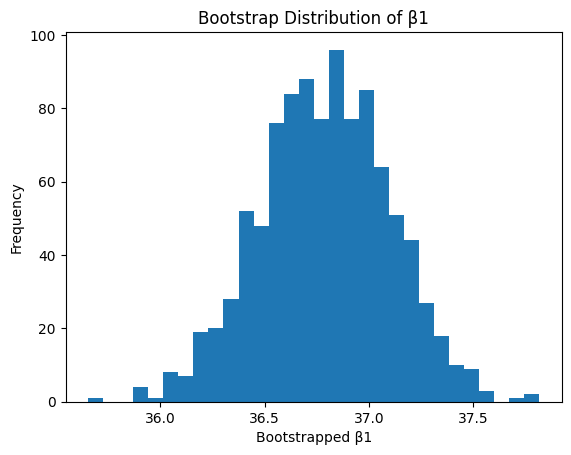

In [16]:
import matplotlib.pyplot as plt

plt.clf()
plt.figure()
plt.hist(boot_betas, bins=30)
plt.xlabel("Bootstrapped β1")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of β1")
plt.show()